Initial shape: (65188, 46)

Columns in dataset:
['CHROM', 'POS', 'REF', 'ALT', 'AF_ESP', 'AF_EXAC', 'AF_TGP', 'CLNDISDB', 'CLNDISDBINCL', 'CLNDN', 'CLNDNINCL', 'CLNHGVS', 'CLNSIGINCL', 'CLNVC', 'CLNVI', 'MC', 'ORIGIN', 'SSR', 'CLASS', 'Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'DISTANCE', 'STRAND', 'BAM_EDIT', 'SIFT', 'PolyPhen', 'MOTIF_NAME', 'MOTIF_POS', 'HIGH_INF_POS', 'MOTIF_SCORE_CHANGE', 'LoFtool', 'CADD_PHRED', 'CADD_RAW', 'BLOSUM62']

Using target variable: CLNSIGINCL

Raw unique values in CLNSIGINCL:
[nan '424754:Likely_pathogenic' '30118:risk_factor' '60702:Pathogenic'
 '236131:Likely_pathogenic' '236068:Pathogenic' '424760:Pathogenic'
 '7901:Pathogenic' '236091:Pathogenic|236092:Pathogenic|424760:Pathogenic'
 '228471:Uncertain_significance'
 '4297:Pathogenic|424818:Likely_pathogenic|424819:Likely_pathogenic'
 '4334:Pathogenic' '4299:Pathogen

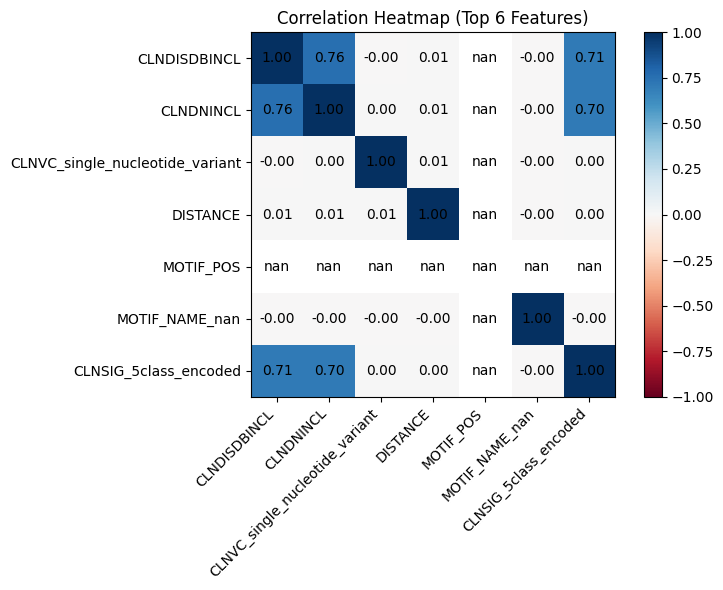

/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


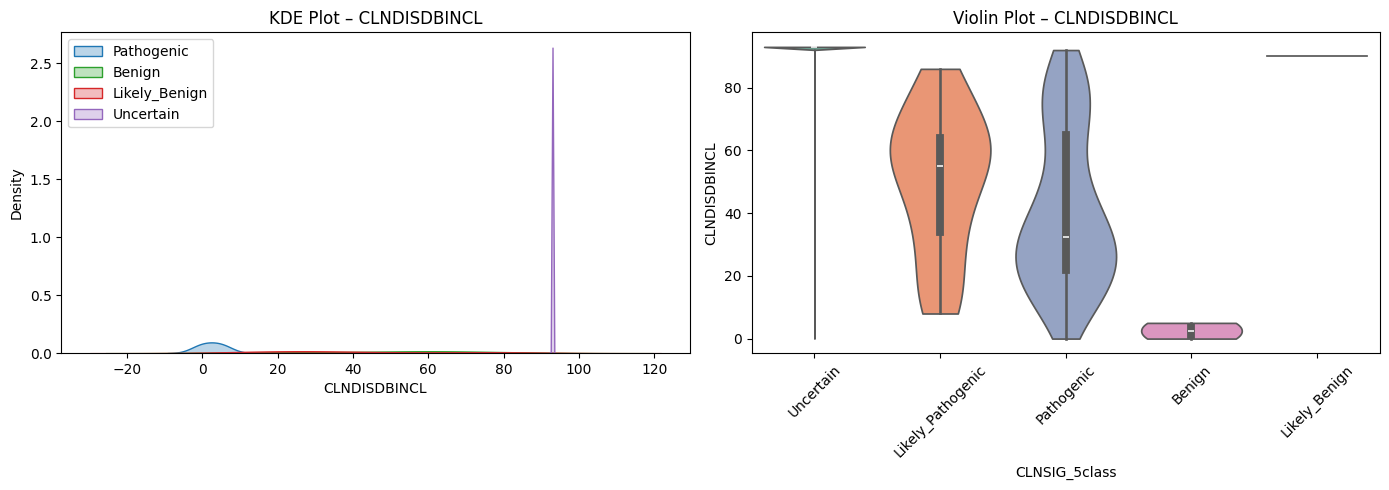

/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


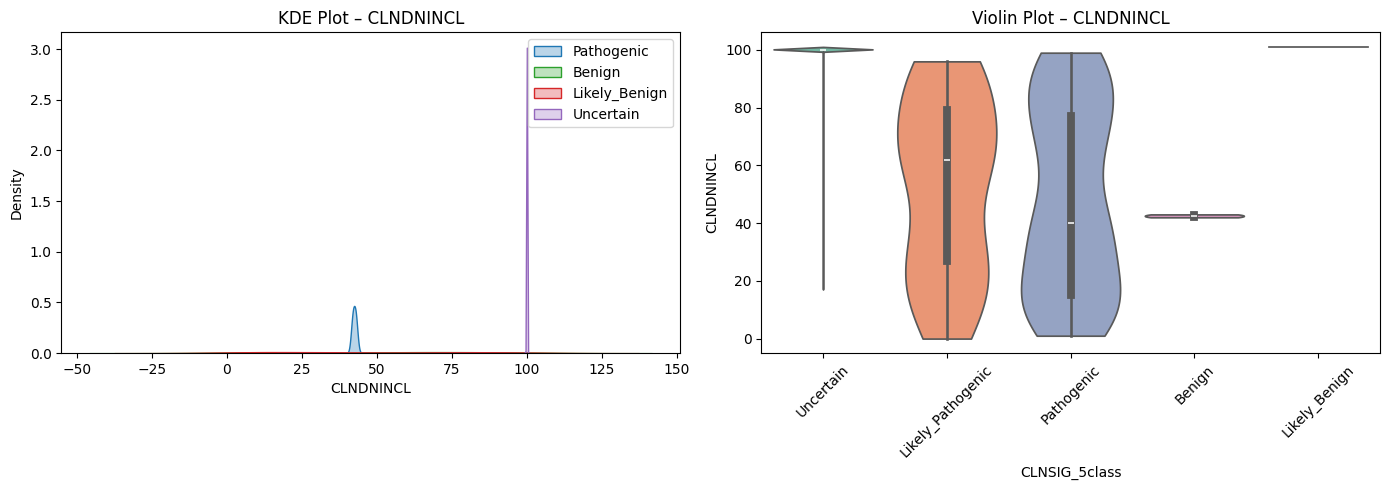

/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


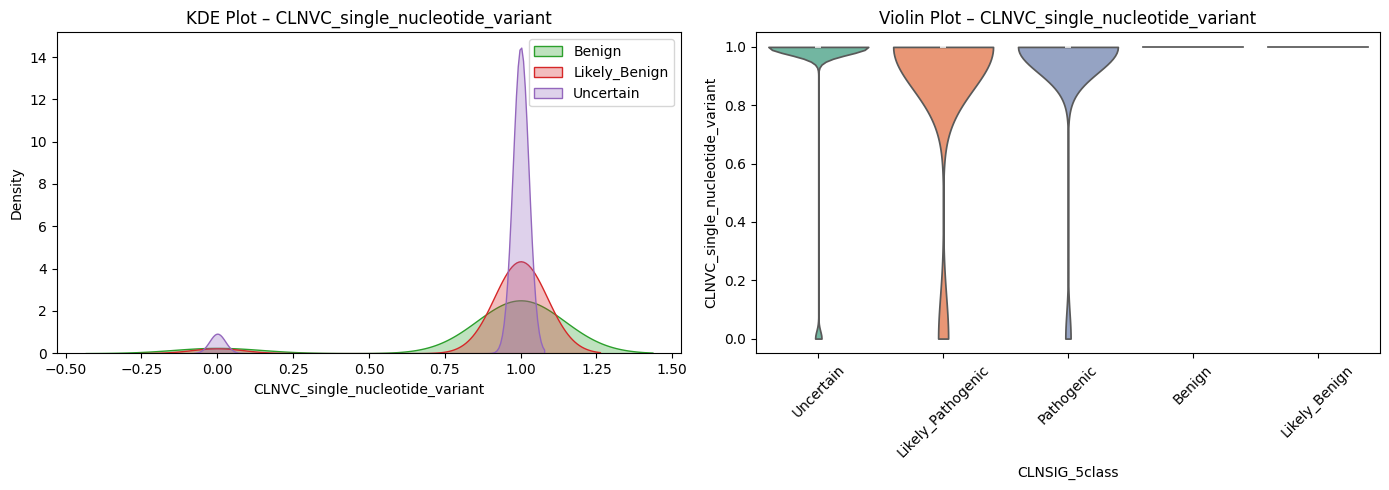

/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


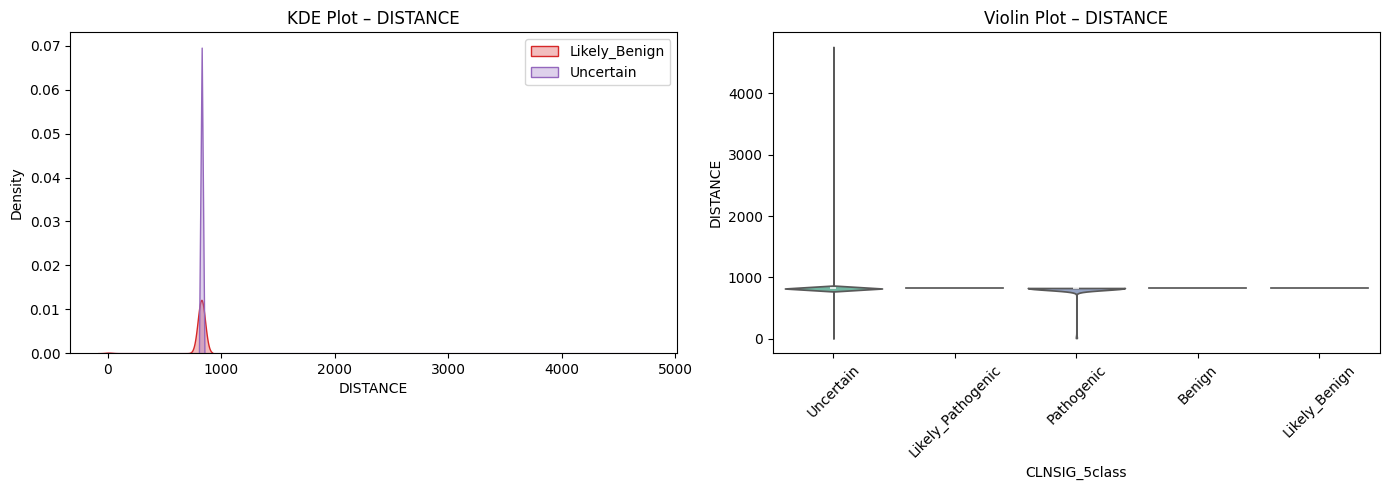

/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:215: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore a

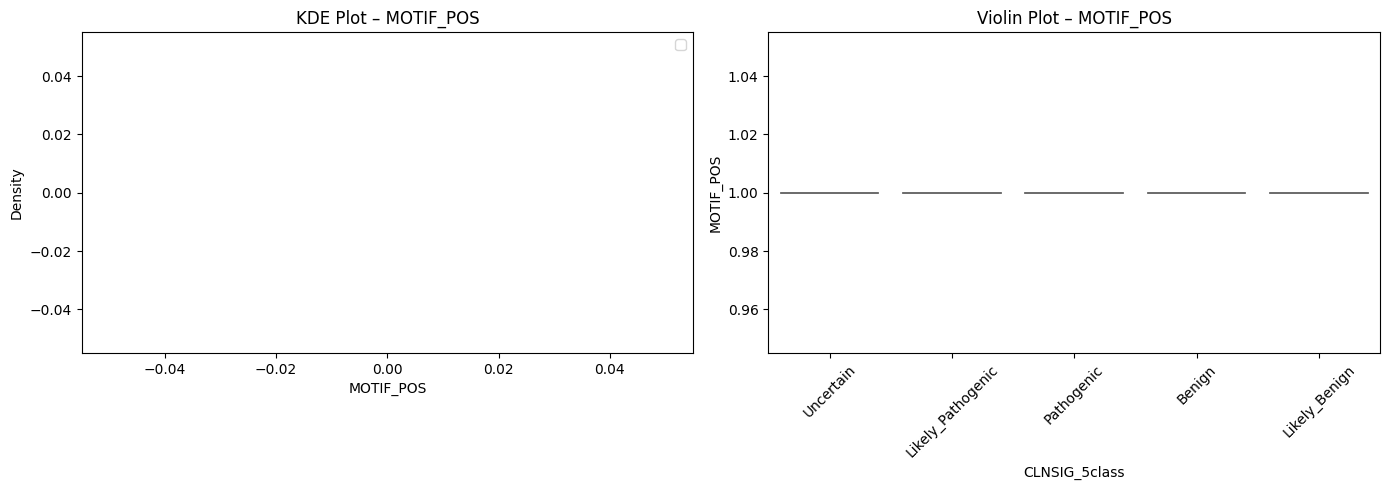

/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:208: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipython-input-2190087719.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


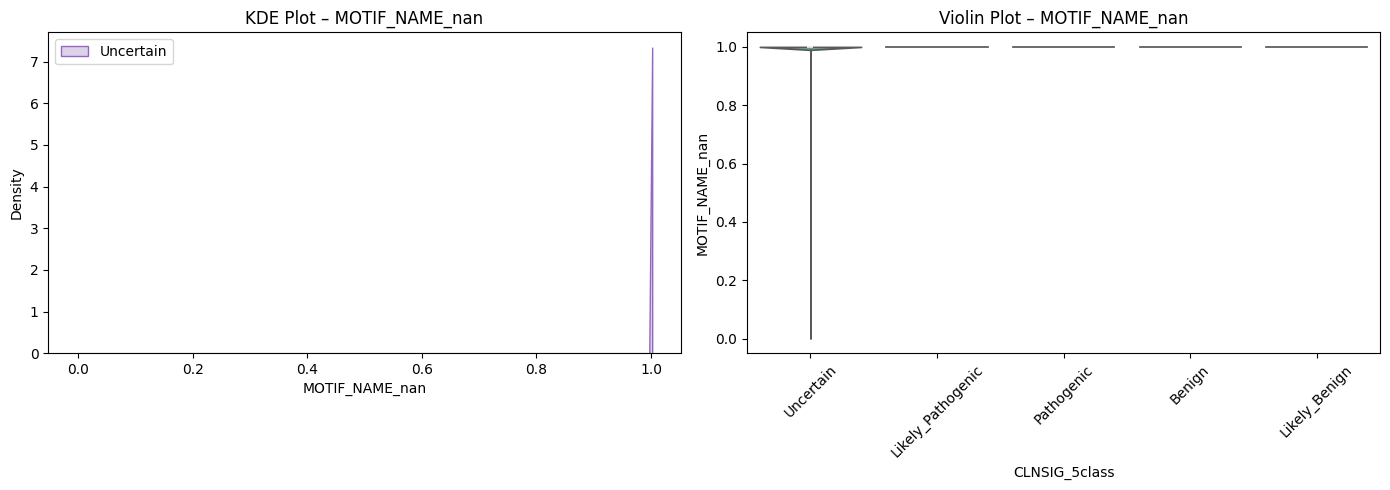


Processing completed successfully.


In [ ]:
# ============================================
# ClinVar Variant Processing – Full Code
# Target = CLNSIGINCL → mapped to 5 clean classes
# ============================================

# Kittu - start
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

FILE_PATH = "clinvar_conflicting.csv"
df = pd.read_csv(FILE_PATH, low_memory=False)
print("Initial shape:", df.shape)

# --------------------------------------------
# 2. FIND TARGET COLUMN (ROBUST MATCHING)
# --------------------------------------------
print("\nColumns in dataset:")
print(df.columns.tolist())

target_candidates = [c for c in df.columns if c.strip().lower() == "clnsigincl"]

if len(target_candidates) == 0:
    raise ValueError("Column 'CLNSIGINCL' NOT FOUND. Check column names.")
else:
    target_col = target_candidates[0]

print("\nUsing target variable:", target_col)

# Show raw unique values
print("\nRaw unique values in CLNSIGINCL:")
print(df[target_col].unique())

# --------------------------------------------
# 3. CREATE 5-CLASS TARGET VARIABLE
# --------------------------------------------
def classify_label(value):
    if pd.isna(value):
        return "Uncertain"

    v = str(value).lower()

    if "likely_benign" in v:
        return "Likely_Benign"
    if "likely_pathogenic" in v:
        return "Likely_Pathogenic"
    if "benign" in v and "likely" not in v:
        return "Benign"
    if "pathogenic" in v and "likely" not in v:
        return "Pathogenic"
    if "uncertain" in v or "risk_factor" in v or "other" in v:
        return "Uncertain"

    return "Uncertain"

df["CLNSIG_5class"] = df[target_col].apply(classify_label)

print("\nValue counts for cleaned 5-class target:")
print(df["CLNSIG_5class"].value_counts())

# Kittu - end

# Pranavi - start

# --------------------------------------------
# 4. REMOVE DUPLICATES
# --------------------------------------------
dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)

if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

# --------------------------------------------
# 5. DETECT NUMERIC & CATEGORICAL COLUMNS
# --------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Convert numeric-like objects
for c in df.select_dtypes(include=["object"]).columns:
    coerced = pd.to_numeric(df[c], errors="coerce")
    if coerced.notna().mean() > 0.6:
        df[c + "_coerced"] = coerced
        numeric_cols.append(c + "_coerced")

numeric_cols = list(dict.fromkeys(numeric_cols))
cat_cols = [c for c in df.columns if c not in numeric_cols and c != "CLNSIG_5class"]

print("\nNumeric columns:", len(numeric_cols))
print("Categorical columns:", len(cat_cols))

# --------------------------------------------
# 6. REMOVE FULLY-MISSING NUMERIC COLUMNS
# --------------------------------------------
numeric_with_nans = [c for c in numeric_cols if df[c].isna().any()]
fully_missing = [c for c in numeric_with_nans if df[c].notna().sum() == 0]

print("\nFully missing numeric columns:", fully_missing)

df = df.drop(columns=fully_missing)
numeric_with_nans = [c for c in numeric_with_nans if c not in fully_missing]

# --------------------------------------------
# 7. IMPUTATION (MEAN)
# --------------------------------------------
mean_df = df.copy()

if numeric_with_nans:
    imputer = SimpleImputer(strategy="mean")
    mean_df[numeric_with_nans] = imputer.fit_transform(mean_df[numeric_with_nans])

df = mean_df

# --------------------------------------------
# 8. OUTLIER FIXING (IQR CAPPING)
# --------------------------------------------
def cap_outliers(series):
    if not np.issubdtype(series.dtype, np.number):
        return series
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return series
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower, upper)

for col in numeric_cols:
    if col in df.columns:
        df[col] = cap_outliers(df[col])

# --------------------------------------------
# 9. ENCODING (One-Hot + Label Encoding)
# --------------------------------------------
df = df.drop(columns=[target_col])

# One-hot encoding for low-cardinality categorical columns
ohe_cols = [c for c in cat_cols if c in df.columns and 1 < df[c].nunique() < 30]
print("\nColumns to one-hot encode:", ohe_cols)

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

if ohe_cols:
    ohe_data = ohe.fit_transform(df[ohe_cols].astype(str))
    ohe_names = ohe.get_feature_names_out(ohe_cols)
    ohe_df = pd.DataFrame(ohe_data, columns=ohe_names, index=df.index)
    df = pd.concat([df.drop(columns=ohe_cols), ohe_df], axis=1)

# Label encode remaining object columns
remaining_obj = [c for c in df.columns if df[c].dtype == object and c != "CLNSIG_5class"]

for c in remaining_obj:
    try:
        df[c] = LabelEncoder().fit_transform(df[c].astype(str))
    except:
        df = df.drop(columns=[c])

# Encode 5-class target
df["CLNSIG_5class_encoded"] = LabelEncoder().fit_transform(df["CLNSIG_5class"])

print("\nFinal dataset shape:", df.shape)

# Pranavi - end

# Jahnavi - start

# --------------------------------------------
# 10. FEATURE SELECTION (Mutual Information)
# --------------------------------------------
X = df.drop(columns=["CLNSIG_5class", "CLNSIG_5class_encoded"])
y = df["CLNSIG_5class_encoded"]

X_num = X.select_dtypes(include=[np.number]).fillna(0)

mi_scores = mutual_info_classif(X_num, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_num.columns).sort_values(ascending=False)

top6 = mi_series.head(6).index.tolist()
print("\nTop 6 selected features:", top6)

# --------------------------------------------
# 11. OLD CORRELATION PLOT (REQUESTED)
# --------------------------------------------
corr = df[top6 + ["CLNSIG_5class_encoded"]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

plt.title("Correlation Heatmap (Top 6 Features)")
plt.tight_layout()
plt.show()

# Jahnavi - end

#Priya - start

# --------------------------------------------
# 12. ADVANCED EDA (KDE + VIOLIN PLOTS)
# --------------------------------------------
class_labels = ["Pathogenic", "Likely_Pathogenic", "Benign", "Likely_Benign", "Uncertain"]

for feat in top6:
    plt.figure(figsize=(14,5))

    # KDE Plot
    plt.subplot(1,2,1)
    for c in range(5):
        sns.kdeplot(
            df[df["CLNSIG_5class_encoded"] == c][feat],
            label=class_labels[c],
            fill=True, alpha=0.3
        )
    plt.title(f"KDE Plot – {feat}")
    plt.xlabel(feat)
    plt.legend()

    # Violin Plot
    plt.subplot(1,2,2)
    sns.violinplot(
        x=df["CLNSIG_5class"],
        y=df[feat],
        palette="Set2",
        cut=0
    )
    plt.title(f"Violin Plot – {feat}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

print("\nProcessing completed successfully.")

#Priya - end
